In [24]:
!pip install matplotlib pandas numpy

In [25]:
import pandas as pd


In [26]:
import numpy as np

In [27]:
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv("C:/Users/ada/OneDrive/Desktop/business_project/data/Sample - superstore.csv" , encoding = 'ISO-8859-9')

In [29]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [31]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [32]:
df.shape

(9994, 21)

In [33]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [34]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

In [35]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Profit Margin %'],
      dtype='object')

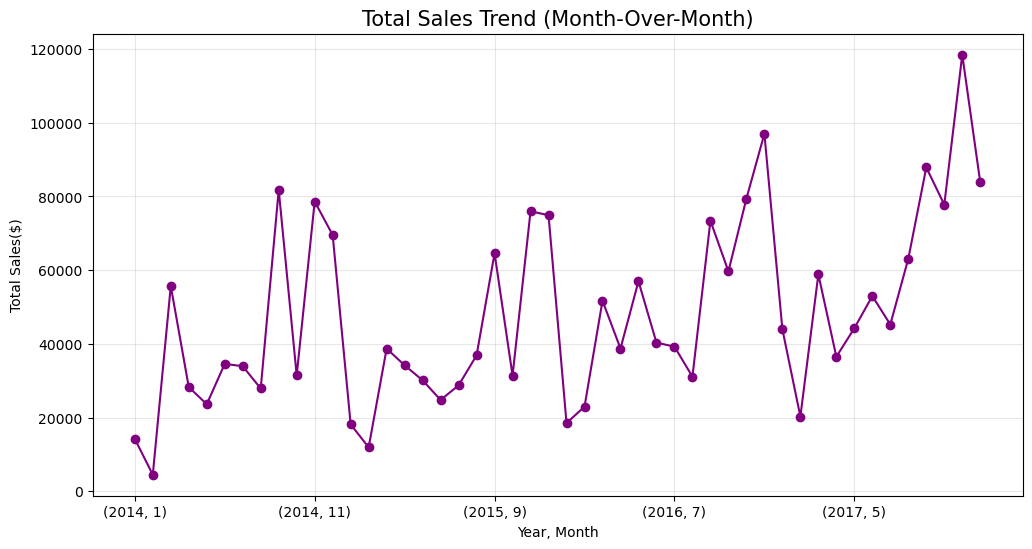

In [36]:
plt.figure(figsize= (12, 6))
df.groupby(['Year','Month']) ['Sales'].sum().plot(kind='line' , marker='o', color='#800080')
plt.title('Total Sales Trend (Month-Over-Month)', fontsize=15)
plt.xlabel('Year, Month')
plt.ylabel('Total Sales($)')
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

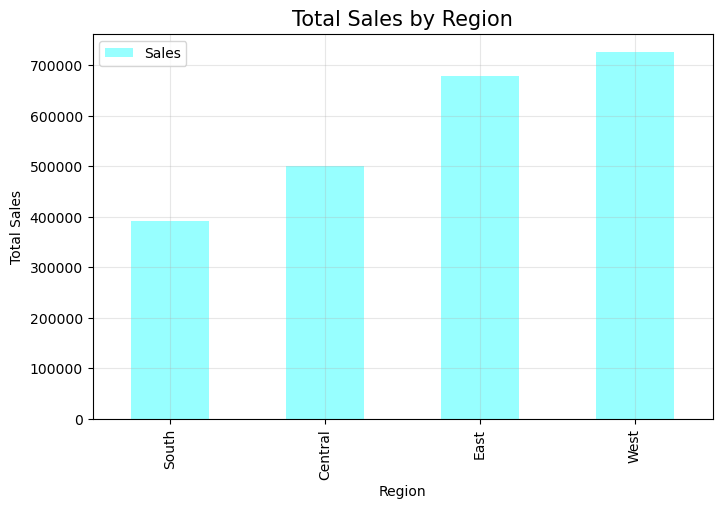

In [38]:

plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.sort_values().plot(
    kind='bar',
    color='#97ffff'
)

plt.title('Total Sales by Region' , fontsize=15)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.legend(['Sales'])
plt.grid(True, alpha=0.3)

plt.show()

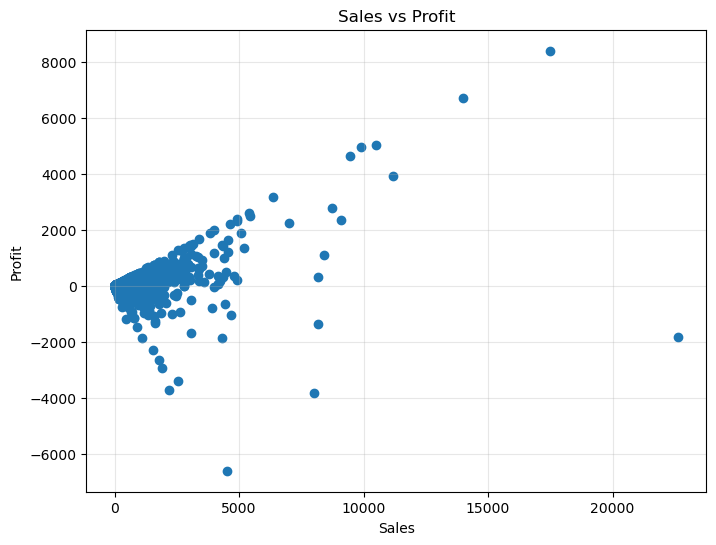

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(df['Sales'], df['Profit'])
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True, alpha=0.3)

plt.show()

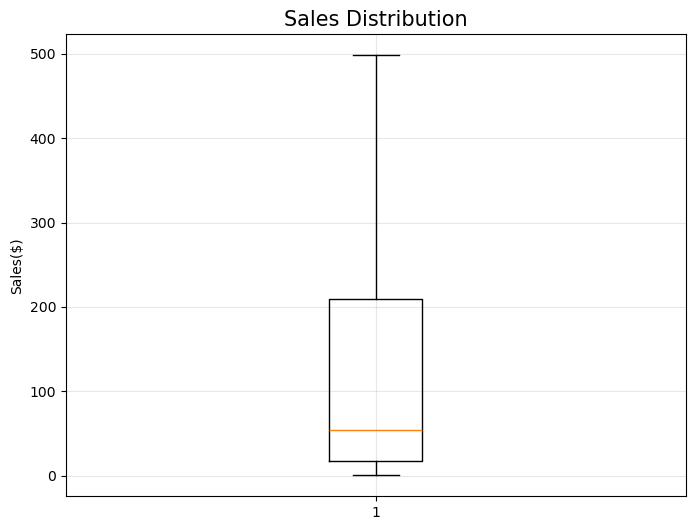

In [40]:
plt.figure(figsize=(8,6))
plt.boxplot(df['Sales'] , showfliers = False)

plt.title('Sales Distribution', fontsize=15)
plt.ylabel('Sales($)')
plt.grid(True, alpha=0.3)

plt.show()


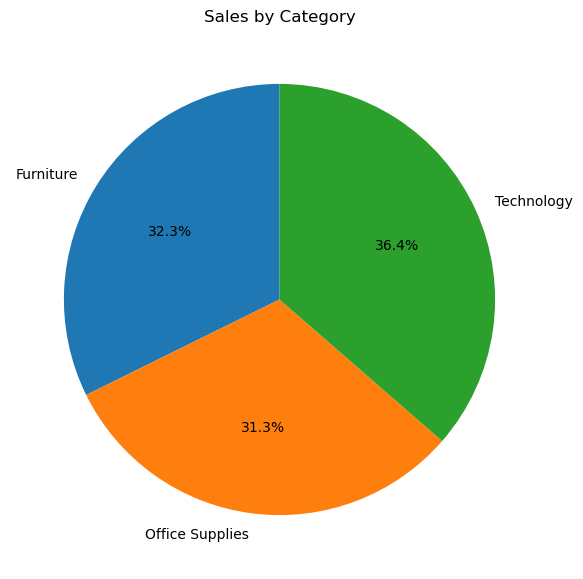

In [43]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize = (7,7))

plt.pie(
    category_sales,
    labels = category_sales.index,
    autopct = '%1.1f%%',
    startangle = 90
)

plt.title("Sales by Category")
plt.show()